# Sonata + linear head — urban tree segmentation

Frozen **Sonata** (self-supervised PTv3) encoder, multi-scale features upcast to full point resolution,
a 2-class linear head trained on **WHU-STree**, then inference on a 100x100 m tile cut from the
13.72 GB campus LAZ.

**Requirements:** GPU accelerator + Internet ON. **Run cells in order** — cell 1 must run before any import.

**Data layout (verified, differs from the README)**

```
whu-stree-nj/<tile>/PCD/<run>.ply     x y z intensity tree label
whu-stree-nj/<tile>/hdi/<run>/traj.csv
whu-stree-nj/reference_data/*.npy     field survey subset, not needed here
```

`tree` = instance id (0 = not a tree), `label` = species id (-1 = not a tree). Binary target is `tree > 0`.
One PLY is ~21.7M points / ~890 MB, which is plenty for a linear probe — we download two.

**Licence:** WHU-STree is CC-BY-NC-ND 3.0, Sonata weights CC-BY-NC 4.0. Research only, no redistribution
of derived copies. Cite the WHU-STree paper.

**Expectations:** Sonata was pretrained mostly on indoor RGB-D. Your data is outdoor MLS with intensity
and no colour. This probe is a *diagnostic*: >0.6 tree IoU means the representation transfers and
fine-tuning is worth it; <0.4 means pretrain Sonata on your own unlabeled scans instead.

## 1. Environment guards — run first

`cumm` and `spconv` decide whether to JIT-compile using `pccm.utils.project_is_editable`, which checks
whether a `setup.py` or `.gitignore` exists two directories up from the package — i.e. in
`dist-packages` itself. A stray file there makes every pccm package think it's an editable checkout and
rebuild from source, which fails. Both expose an env var to skip it; the prebuilt `.so` ships in the wheel.

In [ ]:
import os
os.environ['CUMM_DISABLE_JIT'] = '1'
os.environ['SPCONV_DISABLE_JIT'] = '1'

import sys
sp = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages'
for f in ['setup.py', '.gitignore']:
    p = os.path.join(sp, f)
    if os.path.exists(p):
        os.rename(p, p + '.disabled')
        print(f'renamed stray {f} in dist-packages')
print('jit guards set')

## 2. Install

`spconv-cu126` is the newest variant with cp312 wheels (cu120 stops at cp311; cu128 does not exist).
It runs fine on a CUDA 12.8 runtime via minor-version compatibility. `gdown` needs `-U`: the
preinstalled 5.x caps folder listings at 50 files per folder.

In [ ]:
import subprocess, torch, urllib.request

TORCH_V = torch.__version__.split('+')[0]
CU = (torch.version.cuda or '12.4').replace('.', '')
print('torch', TORCH_V, '| cuda', torch.version.cuda, '| python', sys.version.split()[0])

def sh(cmd):
    print('$', cmd)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-1200:]); print(r.stderr[-1200:])
    return r.returncode

sh('pip install -q spconv-cu126')

def index_ok(u):
    try:
        return urllib.request.urlopen(u, timeout=15).status == 200
    except Exception:
        return False

idx = f'https://data.pyg.org/whl/torch-{TORCH_V}+cu{CU}.html'
if index_ok(idx):
    sh(f'pip install -q torch-scatter -f {idx}')
else:
    print('no prebuilt torch-scatter, building from source (~10 min)')
    sh('pip install -q --no-build-isolation torch-scatter')

sh('pip install -q -U "gdown>=6.1"')
sh('pip install -q huggingface_hub timm addict laspy[lazrs] plyfile')
sh('pip install -q open3d "numpy<2"')
sh('pip install -q git+https://github.com/facebookresearch/sonata.git')

If this is a fresh session, **restart the kernel now** (numpy was downgraded and gdown upgraded),
then re-run cell 1 and continue from here.

In [1]:
import os
os.environ['CUMM_DISABLE_JIT'] = '1'
os.environ['SPCONV_DISABLE_JIT'] = '1'

import numpy as np, torch, cumm, spconv, spconv.pytorch, gdown, laspy
from cumm import core_cc
from tqdm.auto import tqdm

import sonata
print('cumm  ', cumm.__version__, '| prebuilt so:', os.path.basename(core_cc.__file__))
print('spconv', spconv.__version__)
print('gdown ', gdown.__version__)
print('numpy ', np.__version__)
print('sonata ok | cuda', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

cumm   0.7.11 | prebuilt so: core_cc.cpython-312-x86_64-linux-gnu.so
spconv 2.3.8
gdown  6.1.0
numpy  1.26.4
sonata ok | cuda True | Tesla T4


## 3. Config

In [2]:
from pathlib import Path

WHU_DRIVE_URL = 'https://drive.google.com/drive/folders/18braC_G3RAi5fn8TZNRe-Vt8q1bYRZqk'
WHU_CITY = 'whu-stree-nj'
WHU_MAX_PLY = 2

CAMPUS_LAZ = '/kaggle/input/datasets/samsuperman12/my-private-lidar-dataset/point_cloud_campus_2025-03-14-12-59-27_result.laz'

TILE_SIZE = 100.0
TILE_CENTER = None
CHUNK_SIZE = 25.0
CHUNK_OVERLAP = 3.0

GRID_SIZE = 0.05
TRAIN_TILE_SIZE = 30.0
MAX_TRAIN_TILES = 40
FEAT_SUBSAMPLE = 40000

WORK = Path('/kaggle/working')
RAW = Path('/kaggle/temp')
CACHE = WORK / 'cache'
CACHE.mkdir(parents=True, exist_ok=True)
RAW.mkdir(parents=True, exist_ok=True)

torch.manual_seed(0)
np.random.seed(0)
print('config ok')

config ok


## 4. Fetch two PLY scenes

The manifest is cached, so the folder walk runs once. We take `.ply` only — the 12k jpgs and the
trajectory csvs are not used.

In [3]:
import json, collections

MANIFEST = CACHE / 'drive_manifest.json'
if MANIFEST.exists():
    listing = json.loads(MANIFEST.read_text())
    print('cached manifest:', len(listing), 'files')
else:
    files = gdown.download_folder(url=WHU_DRIVE_URL, skip_download=True, quiet=True)
    listing = [{'id': f.id, 'path': f.path} for f in files]
    MANIFEST.write_text(json.dumps(listing))
    print('enumerated:', len(listing), 'files')

plys = [f for f in listing
        if f['path'].lower().endswith('.ply') and WHU_CITY.lower() in f['path'].lower()]
plys.sort(key=lambda f: f['path'])
print(f'{len(plys)} ply in {WHU_CITY}')

todo = plys[:WHU_MAX_PLY]
WHU_DIR = RAW / 'whu'
WHU_DIR.mkdir(parents=True, exist_ok=True)

got = []
for f in todo:
    parts = Path(f['path']).parts
    tile = next((p for p in parts if p.isdigit()), 'x')
    dst = WHU_DIR / f"{tile}_{Path(f['path']).name}"
    if not dst.exists():
        print('downloading', f['path'])
        gdown.download(id=f['id'], output=str(dst), quiet=False)
    got.append(dst)

for p in got:
    print(f'  {p.name}  {p.stat().st_size/1e6:.0f} MB')

enumerated: 12464 files
110 ply in whu-stree-nj
downloading whu-stree-nj/00/PCD/1.ply


Downloading...
From (original): https://drive.google.com/uc?id=1OSZvtQ_khZBhQ5-cvlB_PX9vX3icEn03
From (redirected): https://drive.google.com/uc?id=1OSZvtQ_khZBhQ5-cvlB_PX9vX3icEn03&confirm=t&uuid=d62d21c4-9ee8-4634-947e-412d5fd784da
To: /kaggle/temp/whu/00_1.ply
100%|██████████| 891M/891M [00:08<00:00, 102MB/s]  


downloading whu-stree-nj/01/PCD/1-1.ply


Downloading...
From (original): https://drive.google.com/uc?id=1L2Bha6vdZQBv5DJR4P1Ehz97J6fMhBN2
From (redirected): https://drive.google.com/uc?id=1L2Bha6vdZQBv5DJR4P1Ehz97J6fMhBN2&confirm=t&uuid=600bfb20-23c8-4a7d-9303-94439a2db6c3
To: /kaggle/temp/whu/01_1-1.ply
100%|██████████| 582M/582M [00:06<00:00, 85.5MB/s] 

  00_1.ply  891 MB
  01_1-1.ply  582 MB


## 5. Load and tile

The grid subsample flattens 3D cell indices to a single int64 key before `np.unique` — `unique(axis=0)`
on 20M+ rows is painfully slow, the flat version is seconds.

In [48]:
from plyfile import PlyData

def read_ply_scene(path):
    v = PlyData.read(str(path))['vertex'].data
    xyz = np.column_stack([v['x'], v['y'], v['z']]).astype(np.float64)
    inten = np.asarray(v['intensity'], dtype=np.float32)
    inst = np.asarray(v['tree'], dtype=np.int64)
    species = np.asarray(v['label'], dtype=np.int64) if 'label' in v.dtype.names else None
    return xyz, inten, inst, species


def grid_subsample(xyz, feats, size):
    k = np.floor(xyz / size).astype(np.int64)
    k -= k.min(0)
    dim = k.max(0) + 1
    flat = k[:, 0] + k[:, 1] * dim[0] + k[:, 2] * dim[0] * dim[1]
    _, idx = np.unique(flat, return_index=True)
    idx.sort()
    return xyz[idx], [f[idx] for f in feats]


def tile_scene(xyz, inten, lab, tile, min_pts=8000, max_tiles=999):
    o = xyz[:, :2].min(0)
    ij = np.floor((xyz[:, :2] - o) / tile).astype(np.int64)
    keys, inv = np.unique(ij, axis=0, return_inverse=True)
    out = []
    for k in np.random.permutation(len(keys)):
        m = inv == k
        if m.sum() < min_pts:
            continue
        out.append((xyz[m], inten[m], lab[m]))
        if len(out) >= max_tiles:
            break
    return out


train_tiles = []
per_file = MAX_TRAIN_TILES // max(1, len(got)) + 2

for p in got:
    xyz, inten, inst, species = read_ply_scene(p)
    lab = (inst > 0).astype(np.int64)

    if species is not None:
        agree = ((species >= 0) == (lab == 1)).mean()
        print(f'{p.name}: {len(xyz):,} pts | tree {lab.mean():.3f} | '
              f'instances {len(np.unique(inst))-1} | label/tree agreement {agree:.4f}')
    else:
        print(f'{p.name}: {len(xyz):,} pts | tree {lab.mean():.3f}')

    xyz, (inten, lab) = grid_subsample(xyz, [inten, lab], GRID_SIZE)
    print(f'  after {GRID_SIZE} m grid: {len(xyz):,}')
    ts = tile_scene(xyz, inten, lab, TRAIN_TILE_SIZE, max_tiles=per_file)
    train_tiles += ts
    print(f'  -> {len(ts)} tiles')
    del xyz, inten, lab, inst, species

train_tiles = train_tiles[:MAX_TRAIN_TILES]
assert train_tiles
frac = np.mean([t[2].mean() for t in train_tiles])
print(f'\n{len(train_tiles)} tiles | mean tree fraction {frac:.3f}')

rng = np.random.default_rng(0)
order = rng.permutation(len(train_tiles))
train_tiles = [train_tiles[i] for i in order]

split = int(len(train_tiles) * 0.8)
tiles_tr, tiles_va = train_tiles[:split], train_tiles[split:]
print(f'train {len(tiles_tr)} | val {len(tiles_va)}')
print(f'tree frac — train {np.mean([t[2].mean() for t in tiles_tr]):.4f} '
      f'| val {np.mean([t[2].mean() for t in tiles_va]):.4f}')

00_1.ply: 21,743,427 pts | tree 0.274 | instances 143 | label/tree agreement 0.9863
  after 0.05 m grid: 16,319,944
  -> 22 tiles
01_1-1.ply: 14,189,111 pts | tree 0.227 | instances 78 | label/tree agreement 0.9844
  after 0.05 m grid: 11,286,182
  -> 22 tiles

40 tiles | mean tree fraction 0.193
train 32 | val 8
tree frac — train 0.1815 | val 0.2399


## 6. Sonata input

Sonata wants coord + colour + normal (9 channels — it is an indoor RGB-D model at heart). MLS has
neither colour nor normals, so intensity is mapped to greyscale and normals are estimated with Open3D.
This substitution *is* the domain gap, made concrete.

In [36]:
import open3d as o3d

def estimate_normals(xyz, radius=0.5, max_nn=30):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=radius, max_nn=max_nn))
    pcd.normalize_normals()
    return np.asarray(pcd.normals, dtype=np.float32)


USE_INTENSITY = False

def make_point(xyz, inten, segment=None):
    xyz = np.asarray(xyz, dtype=np.float64)
    xyz = xyz - xyz.mean(0, keepdims=True)
    xyz = xyz.astype(np.float32)
    if USE_INTENSITY:
        color = np.repeat((inten.astype(np.float32) / 65535.0)[:, None], 3, axis=1) * 255.0
    else:
        color = np.full((len(xyz), 3), 127.5, dtype=np.float32)
    d = dict(coord=xyz, color=color.astype(np.float32),
             normal=estimate_normals(xyz.astype(np.float64)))
    if segment is not None:
        d['segment'] = segment.astype(np.int64)
    return d

In [37]:
custom_config = dict(enc_patch_size=[1024] * 5, enable_flash=False)
model = sonata.load('sonata', repo_id='facebook/sonata', custom_config=custom_config).cuda()
model.eval()

transform = sonata.transform.Compose([
    dict(type='CenterShift', apply_z=True),
    dict(type='GridSample', grid_size=GRID_SIZE, hash_type='fnv', mode='train',
         return_grid_coord=True, return_inverse=True),
    dict(type='NormalizeColor'),
    dict(type='ToTensor'),
    dict(type='Collect', keys=('coord', 'grid_coord', 'color', 'inverse'),
         feat_keys=('coord', 'color', 'normal')),
])
print('model ready')

Loading checkpoint from HuggingFace: sonata ...
Model params: 108.46M
model ready


### Upcast

Sonata is decoder-free: it returns an encoder ladder, not one vector per point. Each pooling step
recorded which children merged into which parent, so we read that mapping backwards. Two stages get
concatenated (deep + shallow), the rest propagate. `point.inverse` then maps grid-sampled points back
to the original cloud.

In [38]:
@torch.no_grad()
def sonata_feat(pd):
    point = transform(dict(pd))
    for k in point.keys():
        if isinstance(point[k], torch.Tensor):
            point[k] = point[k].cuda(non_blocking=True)
    point = model(point)
    for _ in range(2):
        parent = point.pop('pooling_parent')
        inv = point.pop('pooling_inverse')
        parent.feat = torch.cat([parent.feat, point.feat[inv]], dim=-1)
        point = parent
    while 'pooling_parent' in point.keys():
        parent = point.pop('pooling_parent')
        inv = point.pop('pooling_inverse')
        parent.feat = point.feat[inv]
        point = parent
    return point.feat[point.inverse].float().cpu()


f = sonata_feat(make_point(*tiles_tr[0][:2], segment=tiles_tr[0][2]))
FEAT_DIM = f.shape[1]
print('feature dim', FEAT_DIM, '| points', f.shape[0])

feature dim 1088 | points 22554


## 7. Extract features

In [49]:
import gc

def gpu_free():
    gc.collect()
    torch.cuda.empty_cache()

def try_feat(xyz, inten, lab):
    try:
        return sonata_feat(make_point(xyz, inten, segment=lab)).numpy()
    except torch.cuda.OutOfMemoryError:
        return None

def feat_recursive(xyz, inten, lab, depth=0):
    f = try_feat(xyz, inten, lab)
    if f is not None:
        return [(f, lab)]
    gpu_free()
    if depth >= 6 or len(xyz) < 2000:
        print(f'  dropped {len(xyz):,} pts')
        return []
    ax = 0 if xyz[:, 0].ptp() >= xyz[:, 1].ptp() else 1
    mid = np.median(xyz[:, ax])
    m = xyz[:, ax] < mid
    if m.all() or (~m).all():
        return []
    return (feat_recursive(xyz[m], inten[m], lab[m], depth + 1) +
            feat_recursive(xyz[~m], inten[~m], lab[~m], depth + 1))

def build_set(tiles, sub=FEAT_SUBSAMPLE):
    X, Y = [], []
    for xyz, inten, lab in tqdm(tiles):
        for f, y in feat_recursive(xyz, inten, lab):
            n = min(sub, len(y))
            sel = np.random.choice(len(y), n, replace=False)
            X.append(f[sel]); Y.append(y[sel])
        gpu_free()
    return np.concatenate(X), np.concatenate(Y)

Xtr, Ytr = build_set(tiles_tr)
Xva, Yva = build_set(tiles_va)
print('train', Xtr.shape, '| tree frac', round(float(Ytr.mean()), 4))
print('val  ', Xva.shape, '| tree frac', round(float(Yva.mean()), 4))

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

train (1419862, 1088) | tree frac 0.2157
val   (439058, 1088) | tree frac 0.2643


## 8. Linear head

Weighted CE and model selection on tree IoU. Unweighted CE on a minority class gives a 90%-accurate
model that predicts background everywhere.

In [50]:
import torch.nn as nn

class LinearHead(nn.Module):
    def __init__(self, dim, n=2):
        super().__init__()
        self.norm = nn.BatchNorm1d(dim)
        self.fc = nn.Linear(dim, n)
    def forward(self, x):
        return self.fc(self.norm(x))


def iou_tree(p, y):
    inter = ((p == 1) & (y == 1)).sum()
    union = ((p == 1) | (y == 1)).sum()
    return float(inter) / max(1, int(union))


head = LinearHead(FEAT_DIM).cuda()
opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)

pos = float(Ytr.mean())
w = torch.tensor([pos, 1 - pos]).float().cuda()
w = w / w.sum() * 2
print('class weights (bg, tree):', [round(x, 3) for x in w.tolist()])
crit = nn.CrossEntropyLoss(weight=w)

Xtr_t, Ytr_t = torch.from_numpy(Xtr).float(), torch.from_numpy(Ytr).long()
Xva_t, Yva_t = torch.from_numpy(Xva).float().cuda(), torch.from_numpy(Yva).long().cuda()

best, best_state = 0.0, None
for ep in range(30):
    head.train()
    perm = torch.randperm(len(Xtr_t))
    tot = 0.0
    for i in range(0, len(perm), 8192):
        idx = perm[i:i + 8192]
        xb, yb = Xtr_t[idx].cuda(), Ytr_t[idx].cuda()
        opt.zero_grad()
        loss = crit(head(xb), yb)
        loss.backward(); opt.step()
        tot += loss.item() * len(idx)
    head.eval()
    with torch.no_grad():
        pv = head(Xva_t).argmax(1)
    iou = iou_tree(pv.cpu().numpy(), Yva)
    if iou > best:
        best, best_state = iou, {k: v.clone() for k, v in head.state_dict().items()}
    if ep % 5 == 0 or ep == 29:
        acc = (pv == Yva_t).float().mean().item()
        print(f'ep {ep:2d} | loss {tot/len(perm):.4f} | acc {acc:.4f} | tree IoU {iou:.4f}')

head.load_state_dict(best_state)
print(f'\nbest val tree IoU {best:.4f}')
torch.save({'state_dict': best_state, 'feat_dim': FEAT_DIM, 'iou': best}, WORK / 'linear_head.pth')

class weights (bg, tree): [0.431, 1.569]
ep  0 | loss 0.0597 | acc 0.9810 | tree IoU 0.9324
ep  5 | loss 0.0112 | acc 0.9857 | tree IoU 0.9481
ep 10 | loss 0.0095 | acc 0.9860 | tree IoU 0.9491
ep 15 | loss 0.0086 | acc 0.9866 | tree IoU 0.9513
ep 20 | loss 0.0081 | acc 0.9866 | tree IoU 0.9510
ep 25 | loss 0.0078 | acc 0.9865 | tree IoU 0.9507
ep 29 | loss 0.0076 | acc 0.9861 | tree IoU 0.9494

best val tree IoU 0.9523


## 9. Cut the campus tile

In [51]:
with laspy.open(CAMPUS_LAZ) as f:
    h = f.header
    print('points:', f'{h.point_count:,}')
    print('mins  :', np.round(h.mins, 2))
    print('maxs  :', np.round(h.maxs, 2))
    print('extent:', np.round((h.maxs - h.mins)[:2], 1), 'm')
    print('dims  :', [d.name for d in h.point_format.dimensions])
    MINS, MAXS = np.array(h.mins), np.array(h.maxs)

if TILE_CENTER is None:
    TILE_CENTER = ((MINS[:2] + MAXS[:2]) / 2).tolist()
half = TILE_SIZE / 2
BBOX = (TILE_CENTER[0] - half, TILE_CENTER[0] + half,
        TILE_CENTER[1] - half, TILE_CENTER[1] + half)
print('\ncenter:', np.round(TILE_CENTER, 2), '| bbox:', np.round(BBOX, 2))

points: 1,513,231,012
mins  : [7.35811780e+05 4.76759574e+06 2.08100000e+01]
maxs  : [7.36565320e+05 4.76825151e+06 9.34900000e+01]
extent: [753.5 655.8] m
dims  : ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue']

center: [ 736188.55 4767923.62] | bbox: [ 736138.55  736238.55 4767873.62 4767973.62]


In [52]:
def extract_bbox(path, bbox, grid=GRID_SIZE, chunk=8_000_000):
    x0, x1, y0, y1 = bbox
    xs, ys, zs, its = [], [], [], []
    kept = 0
    with laspy.open(path) as f:
        has_i = 'intensity' in [d.name for d in f.header.point_format.dimensions]
        pbar = tqdm(total=f.header.point_count, unit='pts')
        for pts in f.chunk_iterator(chunk):
            pbar.update(len(pts.x))
            X, Y = np.asarray(pts.x), np.asarray(pts.y)
            m = (X >= x0) & (X < x1) & (Y >= y0) & (Y < y1)
            if not m.any():
                continue
            xs.append(X[m]); ys.append(Y[m]); zs.append(np.asarray(pts.z)[m])
            its.append(np.asarray(pts.intensity, np.float32)[m] if has_i
                       else np.zeros(int(m.sum()), np.float32))
            kept += int(m.sum())
        pbar.close()
    if not kept:
        raise RuntimeError('empty tile — adjust TILE_CENTER')
    xyz = np.column_stack([np.concatenate(xs), np.concatenate(ys), np.concatenate(zs)])
    inten = np.concatenate(its)
    print(f'\nkept {kept:,}')
    xyz, (inten,) = grid_subsample(xyz, [inten], grid)
    print(f'after grid: {len(xyz):,}')
    return xyz, inten

cf = CACHE / f'tile_{int(TILE_CENTER[0])}_{int(TILE_CENTER[1])}_{int(TILE_SIZE)}.npz'
if cf.exists():
    d = np.load(cf)
    tile_xyz, tile_int = d['xyz'], d['inten']
    print('cached tile:', tile_xyz.shape)
else:
    tile_xyz, tile_int = extract_bbox(CAMPUS_LAZ, BBOX)
    np.savez_compressed(cf, xyz=tile_xyz, inten=tile_int)
print('z range:', round(float(tile_xyz[:, 2].min()), 2), round(float(tile_xyz[:, 2].max()), 2))

cached tile: (12407967, 3)
z range: 28.69 53.06


In [53]:
def occupied_density(xyz, cell=1.0):
    k = np.floor(xyz[:, :2] / cell).astype(np.int64)
    _, cnt = np.unique(k, axis=0, return_counts=True)
    return float(np.median(cnt)) / (cell ** 2)

whu_d = np.median([occupied_density(t[0]) for t in tiles_tr])
camp_d = occupied_density(tile_xyz)
print(f'occupied density — WHU {whu_d:.0f} pts/m2 | campus {camp_d:.0f} pts/m2')
print(f'ratio {camp_d/whu_d:.1f}x')

GRID_CAMPUS = GRID_SIZE * np.sqrt(camp_d / whu_d)
print(f'\nGRID_SIZE {GRID_SIZE} -> GRID_CAMPUS {GRID_CAMPUS:.3f} m')

tile_xyz_m, (tile_int_m,) = grid_subsample(tile_xyz, [tile_int], GRID_CAMPUS)
print(f'{len(tile_xyz):,} -> {len(tile_xyz_m):,} pts')
print(f'matched density: {occupied_density(tile_xyz_m):.0f} pts/m2 (target {whu_d:.0f})')

tile_xyz, tile_int = tile_xyz_m, tile_int_m

occupied density — WHU 314 pts/m2 | campus 518 pts/m2
ratio 1.6x

GRID_SIZE 0.05 -> GRID_CAMPUS 0.064 m
12,407,967 -> 7,064,621 pts
matched density: 277 pts/m2 (target 314)


## 10. Inference

In [54]:
def chunk_bboxes(xyz, size, ov):
    x0, y0 = xyz[:, 0].min(), xyz[:, 1].min()
    x1, y1 = xyz[:, 0].max(), xyz[:, 1].max()
    step, out, x = size - ov, [], x0
    while x < x1:
        y = y0
        while y < y1:
            out.append((x, min(x + size, x1 + 1e-6), y, min(y + size, y1 + 1e-6)))
            y += step
        x += step
    return out


import gc

def gpu_free():
    gc.collect()
    torch.cuda.empty_cache()

def try_infer(idx):
    try:
        feat = sonata_feat(make_point(tile_xyz[idx], tile_int[idx])).cuda()
        with torch.no_grad():
            lg = head(feat).cpu().numpy()
        del feat
        return lg
    except torch.cuda.OutOfMemoryError:
        return None

def infer_box(idx, depth=0):
    if len(idx) < 500:
        return
    lg = try_infer(idx)
    if lg is not None:
        lsum[idx] += lg
        lcnt[idx] += 1
        return
    gpu_free()
    if depth >= 6:
        print(f'  giving up on {len(idx):,} pts | '
              f'alloc {torch.cuda.memory_allocated()/1e9:.2f} GB '
              f'reserved {torch.cuda.memory_reserved()/1e9:.2f} GB')
        return
    pts = tile_xyz[idx]
    ax = 0 if pts[:, 0].ptp() >= pts[:, 1].ptp() else 1
    mid = np.median(pts[:, ax])
    left, right = idx[pts[:, ax] < mid], idx[pts[:, ax] >= mid]
    if len(left) == 0 or len(right) == 0:
        return
    infer_box(left, depth + 1)
    infer_box(right, depth + 1)


head.eval()
lsum = np.zeros((len(tile_xyz), 2), np.float32)
lcnt = np.zeros(len(tile_xyz), np.float32)
boxes = chunk_bboxes(tile_xyz, CHUNK_SIZE, CHUNK_OVERLAP)
print(len(boxes), 'chunks')

for bx0, bx1, by0, by1 in tqdm(boxes):
    m = ((tile_xyz[:, 0] >= bx0) & (tile_xyz[:, 0] < bx1) &
         (tile_xyz[:, 1] >= by0) & (tile_xyz[:, 1] < by1))
    infer_box(np.where(m)[0])

cov = lcnt > 0
pred = np.full(len(tile_xyz), -1, np.int64)
pred[cov] = lsum[cov].argmax(1)
probs = np.full(len(tile_xyz), np.nan, np.float32)
probs[cov] = torch.softmax(torch.from_numpy(lsum[cov] / lcnt[cov, None]), 1)[:, 1].numpy()

print(f'\ncovered {cov.mean()*100:.1f}%')
print(f'tree within covered: {(pred[cov] == 1).mean()*100:.2f}%')
print(f'tree overall: {(pred == 1).mean()*100:.2f}%')

25 chunks


  0%|          | 0/25 [00:00<?, ?it/s]


covered 100.0%
tree within covered: 54.43%
tree overall: 54.43%


In [55]:
print('FEAT_DIM      :', FEAT_DIM)
print('GPU           :', torch.cuda.get_device_name(0),
      f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('alloc / reserved:', f'{torch.cuda.memory_allocated()/1e9:.2f} /',
      f'{torch.cuda.memory_reserved()/1e9:.2f} GB')

counts = []
for bx0, bx1, by0, by1 in boxes:
    m = ((tile_xyz[:, 0] >= bx0) & (tile_xyz[:, 0] < bx1) &
         (tile_xyz[:, 1] >= by0) & (tile_xyz[:, 1] < by1))
    counts.append(int(m.sum()))
counts = np.array(counts)
print(f'\ncampus chunk pts: min {counts.min():,} med {int(np.median(counts)):,} max {counts.max():,}')

whu = np.array([len(t[0]) for t in tiles_tr])
print(f'WHU tile pts    : min {whu.min():,} med {int(np.median(whu)):,} max {whu.max():,}')
print(f'\ncampus density  : {counts.max()/(CHUNK_SIZE**2):.0f} pts/m2')
print(f'WHU density     : {np.median(whu)/(TRAIN_TILE_SIZE**2):.0f} pts/m2')

FEAT_DIM      : 1088
GPU           : Tesla T4 15.6 GB
alloc / reserved: 5.16 / 13.95 GB

campus chunk pts: min 61,809 med 300,268 max 1,253,566
WHU tile pts    : min 9,575 med 258,768 max 608,233

campus density  : 2006 pts/m2
WHU density     : 288 pts/m2


## 11. Results

Judge the top-down view first: urban trees should be discrete blobs along paths, not smears across
building walls. Facades lighting up = the indoor-pretraining domain gap.

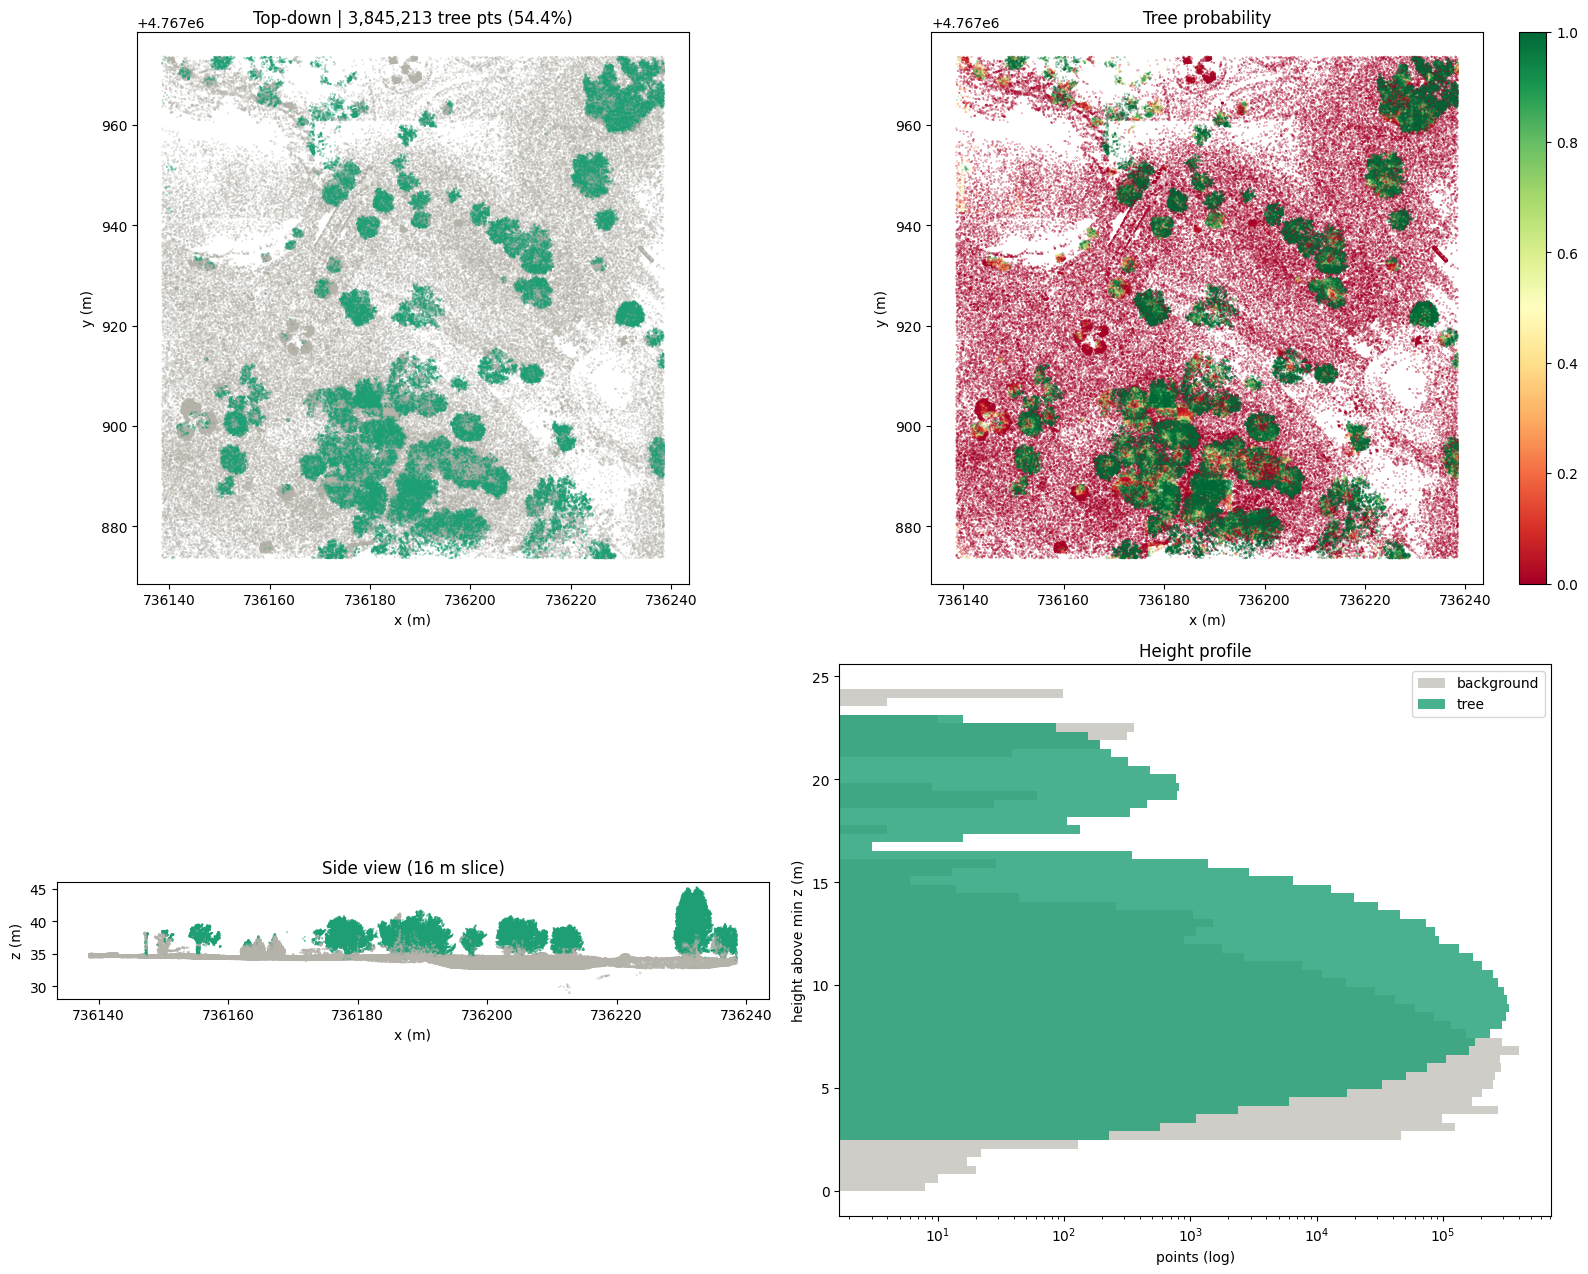

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['#B4B2A9', '#1D9E75'])
tm = pred == 1
fig = plt.figure(figsize=(16, 13))
s = np.random.choice(len(tile_xyz), min(400_000, len(tile_xyz)), replace=False)

ax = fig.add_subplot(2, 2, 1)
ax.scatter(tile_xyz[s, 0], tile_xyz[s, 1], c=pred[s], cmap=cmap, s=0.12, marker='.')
ax.set_title(f'Top-down | {tm.sum():,} tree pts ({tm.mean()*100:.1f}%)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_aspect('equal')

ax = fig.add_subplot(2, 2, 2)
sc = ax.scatter(tile_xyz[s, 0], tile_xyz[s, 1], c=probs[s], cmap='RdYlGn',
                s=0.12, marker='.', vmin=0, vmax=1)
ax.set_title('Tree probability'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal'); plt.colorbar(sc, ax=ax, fraction=0.046)

ax = fig.add_subplot(2, 2, 3)
b = np.where(np.abs(tile_xyz[:, 1] - tile_xyz[:, 1].mean()) < 8)[0]
if len(b) > 200_000:
    b = np.random.choice(b, 200_000, replace=False)
ax.scatter(tile_xyz[b, 0], tile_xyz[b, 2], c=pred[b], cmap=cmap, s=0.2, marker='.')
ax.set_title('Side view (16 m slice)'); ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.set_aspect('equal')

ax = fig.add_subplot(2, 2, 4)
z0 = tile_xyz[:, 2].min()
bins = np.linspace(0, min(30, tile_xyz[:, 2].max() - z0), 60)
ax.hist(tile_xyz[~tm, 2] - z0, bins=bins, alpha=0.65, color='#B4B2A9',
        label='background', orientation='horizontal')
ax.hist(tile_xyz[tm, 2] - z0, bins=bins, alpha=0.8, color='#1D9E75',
        label='tree', orientation='horizontal')
ax.set_xscale('log'); ax.set_ylabel('height above min z (m)')
ax.set_xlabel('points (log)'); ax.set_title('Height profile'); ax.legend()

plt.tight_layout()
plt.savefig(WORK / 'tree_segmentation.png', dpi=130, bbox_inches='tight')
plt.show()

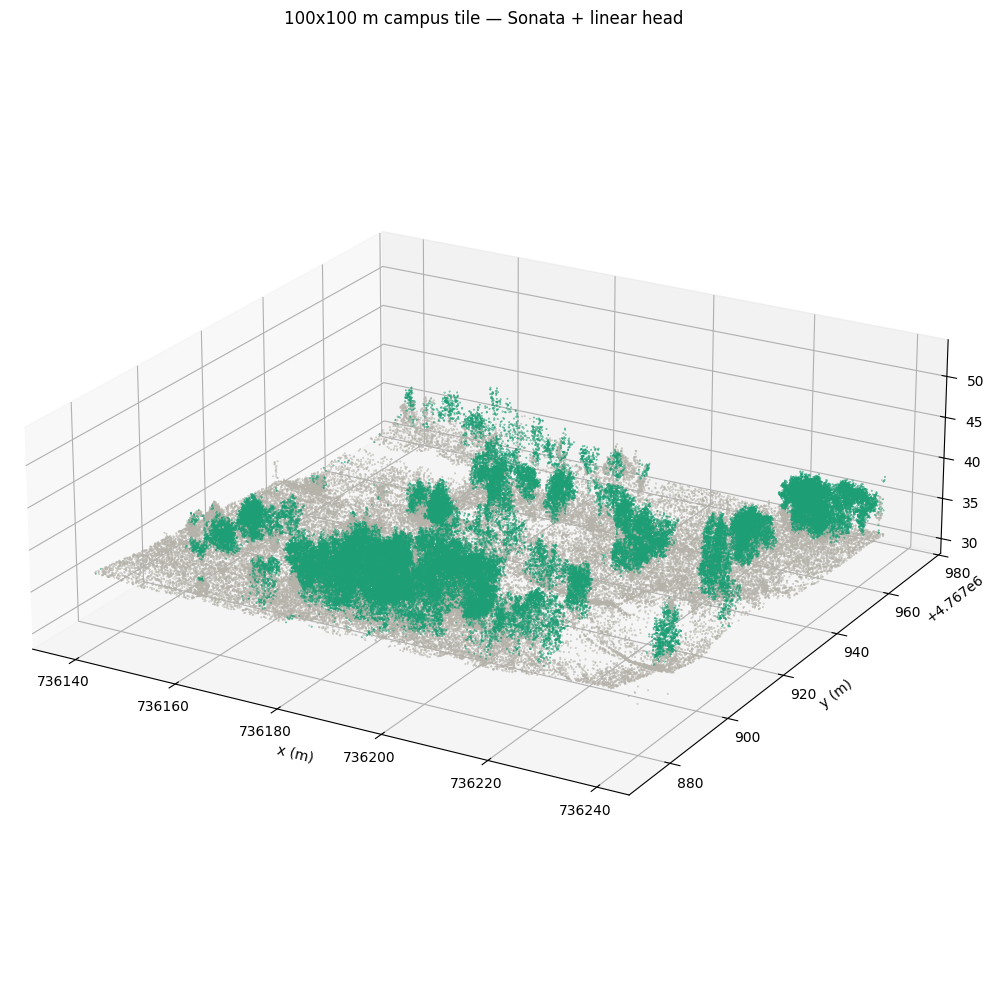

In [57]:
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')
s3 = np.random.choice(len(tile_xyz), min(150_000, len(tile_xyz)), replace=False)
ax.scatter(tile_xyz[s3, 0], tile_xyz[s3, 1], tile_xyz[s3, 2],
           c=pred[s3], cmap=cmap, s=0.4, marker='.', depthshade=False)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.set_title(f'{TILE_SIZE:.0f}x{TILE_SIZE:.0f} m campus tile — Sonata + linear head')
ax.view_init(elev=22, azim=-60)
try:
    ax.set_box_aspect((1, 1, 0.35))
except Exception:
    pass
plt.tight_layout()
plt.savefig(WORK / 'tree_segmentation_3d.png', dpi=130, bbox_inches='tight')
plt.show()

### Export

Tree points get classification 5 (ASPRS high vegetation) so CloudCompare colours them correctly.
`tree_prob` is an extra dimension — threshold it yourself to trade precision against recall.

In [58]:
h = laspy.LasHeader(point_format=3, version='1.2')
h.offsets = tile_xyz.min(0)
h.scales = [0.001, 0.001, 0.001]
out = laspy.LasData(h)
out.x, out.y, out.z = tile_xyz[:, 0], tile_xyz[:, 1], tile_xyz[:, 2]
out.intensity = np.clip(tile_int, 0, 65535).astype(np.uint16)
out.classification = np.where(pred == 1, 5, 1).astype(np.uint8)
out.add_extra_dim(laspy.ExtraBytesParams(name='tree_prob', type=np.float32))
out.tree_prob = probs
out.write(str(WORK / 'campus_tile_segmented.laz'))

np.savez_compressed(WORK / 'campus_tile_pred.npz',
                    xyz=tile_xyz, intensity=tile_int, pred=pred, prob=probs)

for f in sorted(WORK.glob('*')):
    if f.is_file():
        print(f'  {f.name}  {f.stat().st_size/1e6:.1f} MB')
print(f'\nval tree IoU (WHU-STree {WHU_CITY}): {best:.4f}')
print(f'campus tile tree fraction: {pred.mean()*100:.2f}%')

  campus_tile_pred.npz  112.0 MB
  campus_tile_segmented.laz  53.4 MB
  linear_head.pth  0.0 MB
  tree_segmentation.png  2.3 MB
  tree_segmentation_3d.png  0.6 MB

val tree IoU (WHU-STree whu-stree-nj): 0.9523
campus tile tree fraction: 54.43%


## Next steps

1. **Look at it.** Open `campus_tile_segmented.laz` in CloudCompare, filter to class 5. Thirty seconds
   of eyeballing beats the IoU number, which was measured on Nanjing street MLS, not your campus.
2. **Unfreeze.** If the probe holds up, unfreeze the last encoder stage at LR ~1e-5 with the head at
   1e-3, then full fine-tune with layer-wise LR decay.
3. **Use `label` too.** The PLY carries species ids. Once binary works, the same features support a
   19-way species head for free.
4. **Label your own.** A few hundred corrected tiles from your backpack scans beat any amount of head
   tuning on frozen cross-domain features. Use these predictions as pre-labels.
5. **Add Lovász** once fine-tuning end to end — it optimizes IoU directly.